In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from PIL import Image
import requests
from io import BytesIO
import os
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
train_data = tf.keras.utils.image_dataset_from_directory(
    'tomato/train',
    labels='inferred',
    label_mode='categorical',
    image_size=(256, 256),
    batch_size=32
).map(lambda x, y: (x / 255.0, y))

Found 10000 files belonging to 10 classes.


In [4]:
val_data = tf.keras.utils.image_dataset_from_directory(
    'tomato/val',
    labels='inferred',
    label_mode='categorical',
    image_size=(256, 256),
    batch_size=32
).map(lambda x, y: (x / 255.0, y))

Found 1000 files belonging to 10 classes.


In [5]:
conv_base = DenseNet121(weights='imagenet', include_top=False, input_shape=(256, 256, 3), pooling='avg')
conv_base.trainable = False

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [6]:
def extract_features(data):
    features = []
    labels = []
    for images, label in data:
        try :
            feature_batch = conv_base.predict(images)
            features.append(feature_batch)
            labels.append(label)
        except Exception as e:
            print(f"Error occurred while processing {images.file_path}: {e}")
            continue
    return np.vstack(features), np.vstack(labels)

In [7]:
train_features, train_labels = extract_features(train_data)
val_features, val_labels = extract_features(val_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

In [8]:
print("Sample train features (first 5 rows):", train_features[:5])
print("Sample train labels (first 5):", train_labels[:5])
print("Sample validation features (first 5 rows):", val_features[:5])
print("Sample validation labels (first 5):", val_labels[:5])

Sample train features (first 5 rows): [[3.60580685e-04 6.33868761e-03 3.69624281e-03 ... 2.50080347e+00
  2.65734494e-01 7.37246215e-01]
 [3.73694871e-04 6.31516892e-03 4.33551613e-03 ... 1.60872352e+00
  4.11026388e-01 2.17040682e+00]
 [3.14282253e-04 7.99754169e-03 3.69935599e-03 ... 2.34612465e+00
  1.12018354e-01 1.93187332e+00]
 [5.40734211e-04 5.51997172e-03 5.75338863e-03 ... 4.09955597e+00
  4.96734887e-01 1.87771761e+00]
 [3.78592638e-04 4.59104637e-03 5.65911271e-03 ... 4.70631933e+00
  3.24552864e-01 2.58759975e+00]]
Sample train labels (first 5): [[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]]
Sample validation features (first 5 rows): [[3.2880029e-04 2.9491102e-03 2.5110820e-03 ... 4.5826521e+00
  5.1708154e-02 3.9969498e-01]
 [5.4559752e-04 7.2350381e-03 2.5074065e-03 ... 2.5130305e+00
  1.8365341e-01 1.4322510e+00]
 [4.3177963e-04 4.3101506e-03 4.6019121e

# Flatten labels for compatibility


In [9]:
train_labels = np.argmax(train_labels, axis=1)
val_labels = np.argmax(val_labels, axis=1)

In [10]:
print(train_data)
print(val_data)

<_MapDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 10), dtype=tf.float32, name=None))>
<_MapDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 10), dtype=tf.float32, name=None))>


# Train Random Forest Classifier


In [11]:
rf_classifier = RandomForestClassifier(n_estimators=200, random_state=42)
rf_classifier.fit(train_features, train_labels)

RandomForestClassifier(n_estimators=200, random_state=42)

In [12]:
rf_predictions = rf_classifier.predict(val_features)
random_forest_accuracy = accuracy_score(val_labels, rf_predictions)  * 100
print("Random Forest Accuracy:", accuracy_score(val_labels, rf_predictions) * 100)
print("Confusion Matrix (Random Forest):")
print(confusion_matrix(val_labels, rf_predictions))

Random Forest Accuracy: 88.8
Confusion Matrix (Random Forest):
[[ 96   1   0   0   1   0   0   2   0   0]
 [  2  81   7   0   4   2   3   0   1   0]
 [  0   9  86   1   2   0   2   0   0   0]
 [  0   1   0  88   0   1   6   0   4   0]
 [  4   4   2   4  83   0   3   0   0   0]
 [  1   0   0   4   0  88   3   0   3   1]
 [  0   3   1   0   3  12  75   0   1   5]
 [  2   0   0   0   0   1   0  97   0   0]
 [  0   0   0   0   0   0   0   0 100   0]
 [  0   0   0   1   0   0   5   0   0  94]]


# Simple CNN

In [13]:
def create_simple_cnn():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 3)),
        MaxPooling2D((2, 2)),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        BatchNormalization(),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])
    return model

## Training the model with 5 epoch

In [14]:
simple_cnn = create_simple_cnn()
simple_cnn.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
simple_cnn.fit(train_data, epochs=5, validation_data=val_data, callbacks=[EarlyStopping(patience=3)])

Epoch 1/5


c:\Users\tiger\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 220s 696ms/step - accuracy: 0.5439 - loss: 2.0038 - val_accuracy: 0.1510 - val_loss: 9.9204
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 210s 669ms/step - accuracy: 0.7519 - loss: 0.7783 - val_accuracy: 0.6700 - val_loss: 1.4521
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 212s 678ms/step - accuracy: 0.8385 - loss: 0.5177 - val_accuracy: 0.8170 - val_loss: 0.6147
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 204s 652ms/step - accuracy: 0.8851 - loss: 0.3802 - val_accuracy: 0.8630 - val_loss: 0.5634
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 204s 650ms/step - accuracy: 0.9033 - loss: 0.2938 - val_accuracy: 0.8400 - val_loss: 0.6115


In [15]:
simple_cnn_eval = simple_cnn.evaluate(val_data)
simple_cnn_accuracy = simple_cnn_eval[1] * 100
print("Simple CNN Accuracy:", simple_cnn_eval[1] * 100)

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - accuracy: 0.8168 - loss: 0.6918
Simple CNN Accuracy: 83.99999737739563


In [16]:
def create_densenet_cnn():
    model = Sequential([
        conv_base,
        BatchNormalization(),
        Dense(256, activation='relu'),
        Dropout(0.35),
        BatchNormalization(),
        Dense(120, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

In [17]:
densenet_cnn = create_densenet_cnn()
densenet_cnn.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
densenet_cnn.fit(train_data, epochs=17, validation_data=val_data, callbacks=[EarlyStopping(patience=3)])

Epoch 1/17
313/313 ━━━━━━━━━━━━━━━━━━━━ 342s 1s/step - accuracy: 0.3337 - loss: 1.9941 - val_accuracy: 0.7660 - val_loss: 0.9031
Epoch 2/17
313/313 ━━━━━━━━━━━━━━━━━━━━ 334s 1s/step - accuracy: 0.7643 - loss: 0.7633 - val_accuracy: 0.8440 - val_loss: 0.5173
Epoch 3/17
313/313 ━━━━━━━━━━━━━━━━━━━━ 330s 1s/step - accuracy: 0.8293 - loss: 0.5382 - val_accuracy: 0.8800 - val_loss: 0.3933
Epoch 4/17
313/313 ━━━━━━━━━━━━━━━━━━━━ 1686s 5s/step - accuracy: 0.8740 - loss: 0.4006 - val_accuracy: 0.8860 - val_loss: 0.3329
Epoch 5/17
313/313 ━━━━━━━━━━━━━━━━━━━━ 381s 1s/step - accuracy: 0.8908 - loss: 0.3370 - val_accuracy: 0.9060 - val_loss: 0.2914
Epoch 6/17
313/313 ━━━━━━━━━━━━━━━━━━━━ 413s 1s/step - accuracy: 0.9079 - loss: 0.2833 - val_accuracy: 0.9130 - val_loss: 0.2576
Epoch 7/17
313/313 ━━━━━━━━━━━━━━━━━━━━ 421s 1s/step - accuracy: 0.9243 - loss: 0.2330 - val_accuracy: 0.9230 - val_loss: 0.2337
Epoch 8/17
313/313 ━━━━━━━━━━━━━━━━━━━━ 423s 1s/step - accuracy: 0.9339 - loss: 0.2052 - val_acc

In [18]:
densenet_cnn_eval = densenet_cnn.evaluate(val_data)
print("DenseNet CNN Accuracy:", densenet_cnn_eval[1] * 100)
densenet_cnn_accuracy = densenet_cnn_eval[1] * 100

32/32 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.9548 - loss: 0.1505
DenseNet CNN Accuracy: 95.09999752044678


In [19]:
def predict_from_url(url, model, model_type='densenet'):
    response = requests.get(url)
    img = Image.open(BytesIO(response.content)).resize((256, 256))
    img_array = np.expand_dims(np.array(img) / 255.0, axis=0)

    if model_type == 'rf':
        features = conv_base.predict(img_array)
        prediction = model.predict(features)
        predicted_label = np.argmax(prediction)
    elif model_type == 'simple_cnn':
        prediction = model.predict(img_array)
        predicted_label = np.argmax(prediction)
    elif model_type == 'densenet':
        prediction = model.predict(img_array)
        predicted_label = np.argmax(prediction)

    return predicted_label

In [20]:
class_labels = [
    "Bacterial Spot", 
    "Early Blight",   
    "Healthy",   
    "Late Blight",
    "Leaf Mold",
    "Septoria leaf spot",
    "Two Spotted Spider mite",
    "Target spot",
    "mosaic virus",
    "yellow leaf virus"
]

In [21]:
example_url = "https://imgs.search.brave.com/uz3gL-xyiTp9T-ffOfowK0tgQKpmUfNZeB9aiXebHYY/rs:fit:860:0:0:0/g:ce/aHR0cHM6Ly9wbGFu/dGNhcmV0b2RheS5j/b20vd3AtY29udGVu/dC91cGxvYWRzL3Rv/bWF0by15ZWxsb3ct/bGVhdmVzLTEyMDAt/NjMwLUZCLTAzMzEy/MDE5LW1pbi5qcGc"
predicted_rf_disease = predict_from_url(example_url, rf_classifier, model_type='rf')
predicted_simple_cnn_disease = predict_from_url(example_url, simple_cnn, model_type='simple_cnn')
predicted_densenet_disease = predict_from_url(example_url, densenet_cnn, model_type='densenet')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [22]:
predicted_rf_disease_name = class_labels[predicted_rf_disease]
predicted_simple_cnn_disease_name = class_labels[predicted_simple_cnn_disease]
predicted_densenet_disease_name = class_labels[predicted_densenet_disease]

In [23]:
print("Predicted Disease Label (Random Forest):", predicted_rf_disease_name)
print("Predicted Disease Label (Simple CNN):", predicted_simple_cnn_disease_name)
print("Predicted Disease Label (DenseNet CNN):", predicted_densenet_disease_name)

Predicted Disease Label (Random Forest): Bacterial Spot
Predicted Disease Label (Simple CNN): Healthy
Predicted Disease Label (DenseNet CNN): Healthy


C:\Users\tiger\AppData\Local\Temp\ipykernel_3656\3238778116.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracies, palette='Oranges_d')


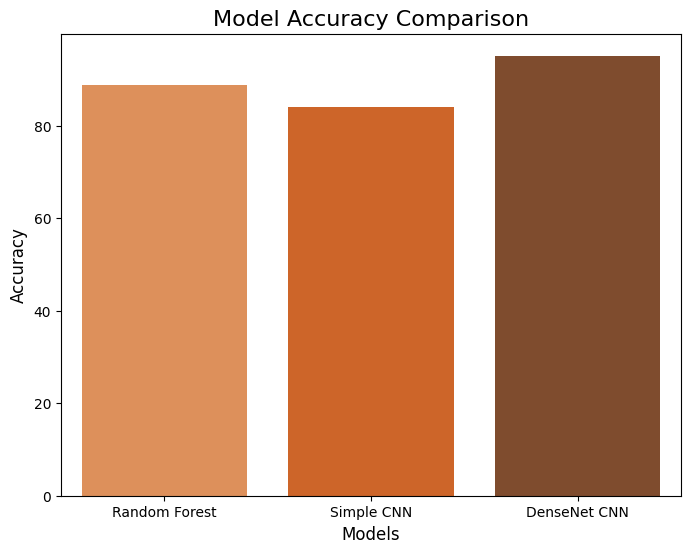

In [24]:
model_names = ['Random Forest', 'Simple CNN', 'DenseNet CNN']
accuracies = [random_forest_accuracy, simple_cnn_accuracy, densenet_cnn_accuracy]  # Replace with actual accuracy values

# Create a bar plot for model accuracies
plt.figure(figsize=(8, 6))
sns.barplot(x=model_names, y=accuracies, palette='Oranges_d')

# Add labels and title
plt.title('Model Accuracy Comparison', fontsize=16)
plt.xlabel('Models', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)

# Show the plot
plt.show()

In [25]:
densenet_predictions = np.argmax(densenet_cnn.predict(val_data), axis=1)
simple_cnn_predictions = np.argmax(simple_cnn.predict(val_data), axis=1)

32/32 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step


In [26]:
densenet_cm = confusion_matrix(val_labels, densenet_predictions)
print(densenet_cm)

[[ 6  8 11  8  6 12 11 12 18  8]
 [12 15  8 10  4 14 13  9  8  7]
 [10  4 10 14  7  8  6 14 13 14]
 [15  9  8  8  7 12  6 19  9  7]
 [10 11 10  8 16 12  6  6 12  9]
 [ 9  6  8 14 11 10  8 12  7 15]
 [11 14 13  5  7  9 14 10 10  7]
 [11  8 14  6 13 14 11  7  8  8]
 [10  4 11 16 12  7  9  6 14 11]
 [ 9 18 12  9 13  3  8  6  7 15]]


In [27]:
simple_cnn_cm = confusion_matrix(val_labels, simple_cnn_predictions)
print(simple_cnn_cm)

[[10 13 12 11 14  9 10  4  7 10]
 [11 13 12  9  7 15  8  7  8 10]
 [ 9 11  5  4 10 13 11 12 13 12]
 [ 9 12  8 10  9 12  8 11 19  2]
 [ 7 13 12  7 15 12  8  6 11  9]
 [10 12  7 10 13 11 10 13  6  8]
 [12 13  9 11  8  9 10  5 14  9]
 [ 8 13 11  5 10 14  8 13 13  5]
 [ 7 13 12  6 10  7 12 12 11 10]
 [ 8 13 13  7 12 12 15  5  7  8]]


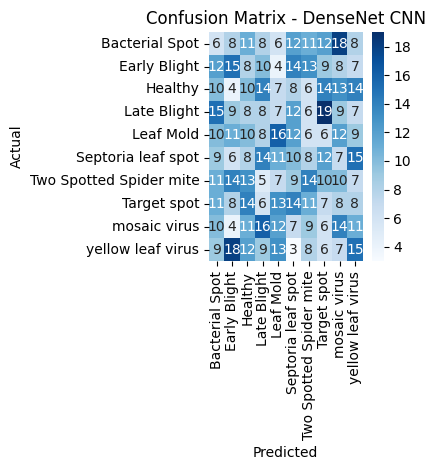

In [28]:
plt.subplot(1, 2, 1)
sns.heatmap(densenet_cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - DenseNet CNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

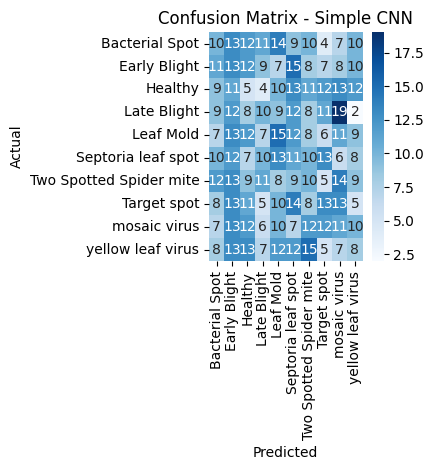

In [29]:
plt.subplot(1, 2, 2)
sns.heatmap(simple_cnn_cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - Simple CNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [30]:
densenet_cnn.save("densenet_tomato_model.h5")

In [44]:
from tensorflow.keras.applications import DenseNet121

# Load DenseNet121 base model
conv_base = DenseNet121(weights='imagenet', include_top=False, input_shape=(256, 256, 3), pooling='avg')

# Find last Conv2D layer and print info
for i in reversed(range(len(conv_base.layers))):
    layer = conv_base.layers[i]
    if layer.__class__.__name__ == 'Conv2D':
        print(f"Last Conv2D layer: index {i}, name: {layer.name}, output shape: {layer.output.shape}")
        break


Last Conv2D layer: index 423, name: conv5_block16_2_conv, output shape: (None, 8, 8, 32)
